# CaImAn vs our CNMFe — head-to-head on a synthetic movie

Runs both pipelines on the same ground-truth synthetic 1p movie and compares:

1. **Spatial recovery** — per-neuron Pearson r between each pipeline's `A` and the true footprints
2. **Temporal recovery** — per-neuron Pearson r between `C + YrA` (the noisy projected trace) and the true calcium trace

`C + YrA` is used for the temporal comparison because it preserves the data's actual shape; OASIS-deconvolved `C` alone has small spike-timing distortions that drag Pearson down to ~0.85 even for a perfect extraction (see `tutorial2.ipynb` cell 26 for the why).

**Prerequisites**: launch this notebook from a conda env that has CaImAn installed (e.g. `conda activate caiman_claude_nmfe; jupyter notebook`). The notebook just does `import caiman` — no local source-tree path hacks.

In [1]:
import os, tempfile, time

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Generate the synthetic movie

Same fixture as `tutorial2.ipynb` so results are directly comparable.

In [2]:
from tests.conftest import make_synthetic_movie

data = make_synthetic_movie(n_neurons=10, dims=(64, 64), T=6500,
                            noise_std=0.5, ar_decay=0.9, bg_strength=2.0, seed=55)

movie    = data['movie']     # (T, H, W) float32
A_true   = data['A_true']    # (H*W, K)
C_true   = data['C_true']    # (K, T)
centers  = data['centers']   # (K, 2)
T, H, W  = movie.shape
K        = C_true.shape[0]

print(f'Movie: {movie.shape}   neurons={K}   noise_std={data["sn_true"]}   g_true={data["ar_decay"]}')

Movie: (6500, 64, 64)   neurons=10   noise_std=0.5   g_true=0.9


## 2. Helpers — Pearson, normalisation, neuron matching

`match_components_by_truth` pairs each true neuron with whichever extracted neuron has the highest spatial correlation, returning `(true_idx, est_idx, spatial_r)`. We use the same helper for both pipelines so the comparison is symmetric.

In [3]:
def pearson(a, b):
    a = a - a.mean(); b = b - b.mean()
    d = np.sqrt(np.sum(a ** 2) * np.sum(b ** 2))
    return float(np.dot(a, b) / d) if d > 0 else 0.0

def norm01(x):
    lo, hi = float(np.min(x)), float(np.max(x))
    return (x - lo) / (hi - lo + 1e-10)

def match_components_by_truth(A_est, A_true_dense):
    """Pair each true neuron with the extracted component that best matches it
    spatially. Returns list of (true_idx, est_idx, spatial_r)."""
    A_e = np.asarray(A_est.todense() if sp.issparse(A_est) else A_est)
    A_t = A_true_dense
    matches = []
    if A_e.shape[1] == 0:
        return [(k, -1, 0.0) for k in range(A_t.shape[1])]
    for k_true in range(A_t.shape[1]):
        a_t = A_t[:, k_true]
        corrs = np.array([pearson(a_t, A_e[:, k]) for k in range(A_e.shape[1])])
        best = int(np.argmax(corrs))
        matches.append((k_true, best, float(corrs[best])))
    return matches

## 3. Run our CNMFe pipeline

In [4]:
from cnmfe.pipeline import CNMFe, CNMFeParams

params_ours = CNMFeParams(
    sigma=3.0,
    min_corr=0.8,
    min_pnr=6.0,
    n_iter_main=2,
    n_iter_temporal=2,
    mc_n_iter=1,
    spatial_max_thr=0.1,
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
    global_ar=False,  # per-neuron g estimated from each C_raw[k]
    n_jobs=-1,
)

t0 = time.time()
ours = CNMFe(params_ours).fit(movie, do_motion_correction=False)
t_ours = time.time() - t0

A_ours    = ours.A                            # (H*W, K) sparse
C_ours    = ours.C                            # (K, T)
YrA_ours  = ours.YrA                          # (K, T)
Cproj_ours = C_ours + YrA_ours                # noisy projected trace

print(f'\nours: K = {A_ours.shape[1]}   wall = {t_ours:.2f}s')

Extraction config: n_jobs=-1 device=cpu T=6500 H=64 W=64 streaming=no (movie materialised in RAM)
Estimating noise...
Running greedy CORR-PNR initialization (init_stride=1, T_init=6500; corrpnr_stride=3, T_corrpnr=2166)...
  Found 10 initial components.
Fitting ring-model background (radius=10.5px, tsub=5)...
Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).
Refinement iteration 2/2...
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).
Auto-evaluation: 10/10 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<3.0). All components retained; filter via model.accepted_mask.
Final temporal update...
Done. Extracted 10 neurons.

ours: K = 10   wall = 14.91s


In [5]:
# Iteration-equalised variant: same params but n_iter_main=1 to match CaImAn's
# hardcoded single-cycle structure. Isolates algorithm quality from iteration count.
params_1iter = CNMFeParams(
    sigma=3.0, min_corr=0.8, min_pnr=6.0,
    n_iter_main=1,
    n_iter_temporal=2, mc_n_iter=1,
    spatial_max_thr=0.1, merge_thr_corr=0.85, merge_thr_overlap=0.5,
    global_ar=False,  # per-neuron g estimated from each C_raw[k]
    n_jobs=-1,
)
t0 = time.time()
ours1 = CNMFe(params_1iter).fit(movie, do_motion_correction=False)
t_ours1 = time.time() - t0

A_ours1   = ours1.A
C_ours1   = ours1.C
YrA_ours1 = ours1.YrA
Cproj_ours1 = C_ours1 + YrA_ours1

print(f'\nours (1 iter): K = {A_ours1.shape[1]}   wall = {t_ours1:.2f}s')

Extraction config: n_jobs=-1 device=cpu T=6500 H=64 W=64 streaming=no (movie materialised in RAM)
Estimating noise...
Running greedy CORR-PNR initialization (init_stride=1, T_init=6500; corrpnr_stride=3, T_corrpnr=2166)...
  Found 10 initial components.
Fitting ring-model background (radius=10.5px, tsub=5)...
Refinement iteration 1/1...
  Pre-merging duplicate seeds...
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).
Auto-evaluation: 10/10 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<3.0). All components retained; filter via model.accepted_mask.
Final temporal update...
Done. Extracted 10 neurons.

ours (1 iter): K = 10   wall = 11.38s


## 4. Run CaImAn's CNMF-E pipeline

CaImAn's CNMF-E entry point is `caiman.source_extraction.cnmf.CNMF` configured with
`method_init='corr_pnr'`, `p=1`, `gnb=0`, `low_rank_background=None`, and
`update_background_components=False` — that combination disables the rank-`gnb` global
background and uses the ring model instead.

**Parameters are aligned 1:1 with our model wherever CaImAn exposes the equivalent.**
Two settings required explicit correction from their CaImAn defaults:

- `ssub_B=1` — CaImAn defaults to 2, which computes ring-background weights at half
  spatial resolution before upsampling. Our `compute_W` is always full-resolution.
- `thr_method='max', maxthr=0.1` — CaImAn defaults to energy-based thresholding
  (`'nrg'`). Our `spatial_max_thr=0.1` zeros pixels below 10 % of the footprint peak,
  which corresponds to CaImAn's `'max'` method with `maxthr=0.1`.

**Three structural differences remain** that have no configurable CaImAn equivalent
(see the mapping table in the next cell):

1. **Refinement iterations** — Our model runs `n_iter_main=2` full
   (spatial → temporal → merge) cycles. CaImAn runs exactly 1 cycle (hardcoded).
2. **Merge spatial condition** — Ours requires Jaccard > 0.5 *or* centre-distance
   < 2 σ. CaImAn merges on *any* non-zero pixel overlap meeting the temporal threshold.
3. **Greedy-init extraction thresholds** — `init_min_corr_neuron`, `init_max_corr_bg`,
   and `seed_suppress_factor` have no exposed CaImAn equivalent.

CaImAn requires a memory-mapped movie file rather than an in-memory numpy array, so we
save the movie to disk first. Outputs land on `cnm.estimates`.

In [6]:
import caiman as cm
from caiman.source_extraction.cnmf import cnmf as cnmf_module
from caiman.source_extraction.cnmf import params as params_module

# --- Save the movie as a CaImAn-style memory-mapped file -------------------
mmap_dir = tempfile.mkdtemp()
mmap_base = os.path.join(mmap_dir, 'caiman_movie_')

# CaImAn expects (T, H, W) float32. Save and then load as memmap.
fname_mmap = cm.save_memmap([movie.astype(np.float32)],
                            base_name=mmap_base, order='C')

Yr, mmap_dims, mmap_T = cm.load_memmap(fname_mmap)
images = Yr.T.reshape((mmap_T,) + mmap_dims, order='F')   # (T, H, W) view
print(f'memmap: T={mmap_T}, dims={mmap_dims}, file={fname_mmap}')

memmap: T=6500, dims=(64, 64), file=/home/fs539/caiman_data/temp/caiman_movie_d1_64_d2_64_d3_1_order_C_frames_6500.mmap


### Parameter correspondence table

| Our `CNMFeParams` | CaImAn param | Value | Status |
|---|---|---|---|
| `sigma=3.0` | `gSig=(3,3)` | 3 | ✓ matched |
| `min_corr=0.8` | `min_corr` | 0.8 | ✓ matched |
| `min_pnr=6.0` | `min_pnr` | 6.0 | ✓ matched |
| `ar_order=1` | `p` | 1 | ✓ matched |
| `ring_size_factor=1.5` | `ring_size_factor` | 1.5 | ✓ matched |
| `border_px=5` | `border_pix` | 5 | ✓ matched |
| `center_psf=True` | `center_psf` | True | ✓ matched |
| `merge_thr_corr=0.85` | `merge_thr` | 0.85 | ✓ matched (temporal corr threshold) |
| `spatial_max_thr=0.1` | `thr_method='max', maxthr=0.1` | 0.1 | ✓ matched (explicit — CaImAn default was `'nrg'`) |
| full-res ring bg | `ssub_B=1` | 1 | ✓ matched (CaImAn default was 2) |
| `n_iter_main=2` | *(hardcoded: 1 cycle)* | — | ⚠ structural — CaImAn runs 1 fixed refinement cycle |
| `merge_thr_overlap=0.5` (Jaccard) | *any pixel overlap > 0* | — | ⚠ structural — CaImAn has no Jaccard threshold |
| `merge_centre_dist_factor=2.0` | *(no equivalent)* | — | ⚠ structural — no centre-distance merge fallback |
| `init_min_corr_neuron=0.8` | *(no direct param)* | — | ⚠ structural — CaImAn init uses different internal thresholds |
| `init_max_corr_bg=0.4` | *(no direct param)* | — | ⚠ structural |
| `seed_suppress_factor=2.0` | *(hardcoded in CaImAn greedy init)* | — | ⚠ structural |

Any remaining performance gap after parameter alignment is attributable to the structural differences above.

In [7]:
# --- Configure CaImAn for CNMF-E -------------------------------------------
# Parameters are matched 1:1 to our CNMFeParams where CaImAn exposes an equivalent.
# Structural differences (no configurable fix) are noted in the markdown table above.
gSig = (3, 3)                  # neuron half-size (px) — matches our sigma=3.0
gSiz = (4 * gSig[0] + 1,) * 2  # patch size in greedy init (CaImAn convention)

opts_dict = {
    'fnames':                     [fname_mmap],
    'fr':                         30,                  # fps
    'decay_time':                 0.4,                 # used only for quality metrics, not AR estimation
    'method_init':                'corr_pnr',          # CNMF-E init
    'K':                          None,                # uncapped — matches max_neurons=None
    'gSig':                       gSig,                # matches sigma=3.0
    'gSiz':                       gSiz,
    'merge_thr':                  0.85,                # temporal correlation threshold — matches merge_thr_corr=0.85
    'p':                          1,                   # AR(1) — matches ar_order=1
    'tsub':                       1,                   # no temporal subsampling
    'ssub':                       1,                   # no spatial subsampling
    'rf':                         None,                # no patches (movie is small)
    'stride':                     None,
    'only_init':                  False,
    'nb':                         0,                   # no global low-rank bg (CNMF-E uses ring)
    'nb_patch':                   0,
    'method_deconvolution':       'oasis',             # matches our deconvolution backend
    'low_rank_background':        None,
    'update_background_components': False,
    'min_corr':                   0.8,                 # matches min_corr=0.8
    'min_pnr':                    6.0,                 # matches min_pnr=6.0
    'normalize_init':             False,
    'center_psf':                 True,                # matches center_psf=True
    'ssub_B':                     1,                   # full-resolution ring bg — matches our compute_W (CaImAn default was 2)
    'ring_size_factor':           1.5,                 # matches ring_size_factor=1.5
    'thr_method':                 'max',               # peak-fraction thresholding — matches spatial_max_thr (CaImAn default was 'nrg')
    'maxthr':                     0.1,                 # zero pixels < 10% of peak — matches spatial_max_thr=0.1
    'del_duplicates':             True,                # remove duplicate seeds (like our pre-merge on iter 0)
    'border_pix':                 5,                   # matches border_px=5
}
opts = params_module.CNMFParams(params_dict=opts_dict)


In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


In [8]:
# Shut down joblib's loky worker pool so CaImAn's setup_cluster doesn't see
# it as a pre-existing multiprocessing cluster.
from joblib.externals.loky import get_reusable_executor
get_reusable_executor().shutdown(wait=True)

# --- Cluster (CaImAn requires a multiprocessing pool, even n_processes=1) --
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='multiprocessing', n_processes=1, single_thread=True
)

try:
    t0 = time.time()
    cnm = cnmf_module.CNMF(n_processes=1, dview=dview, Ain=None, params=opts)
    cnm.fit(images)              # mutates cnm in place; do NOT reassign — some
                                 # CaImAn versions return None from fit().
    t_caiman = time.time() - t0
finally:
    cm.cluster.stop_server(dview=dview)

# --- Pull outputs into our standard names ----------------------------------
A_caiman    = cnm.estimates.A                                     # (H*W, K) sparse
C_caiman    = np.asarray(cnm.estimates.C)                         # (K, T)
YrA_caiman  = np.asarray(cnm.estimates.YrA) if cnm.estimates.YrA is not None else \
              np.zeros_like(C_caiman)                              # (K, T)
Cproj_caiman = C_caiman + YrA_caiman

print(f'\ncaiman: K = {A_caiman.shape[1]}   wall = {t_caiman:.2f}s')


caiman: K = 10   wall = 30.05s


/home/fs539/miniforge3/envs/claude_cnmfe/lib/python3.12/site-packages/scipy/sparse/_dia.py:379: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]


In [9]:
# cm.stop_server(
# )

## 5. Spatial recovery — `A` vs `A_true`

For each true neuron we pick whichever extracted component matches it best, then report the spatial Pearson r between those flat footprints. A score above ~0.7 means the extracted footprint genuinely covers the true neuron.

In [10]:
matches_ours   = match_components_by_truth(A_ours,   A_true)
matches_ours1  = match_components_by_truth(A_ours1,  A_true)
matches_caiman = match_components_by_truth(A_caiman, A_true)

rs_A_ours   = np.array([m[2] for m in matches_ours])
rs_A_ours1  = np.array([m[2] for m in matches_ours1])
rs_A_caiman = np.array([m[2] for m in matches_caiman])

fp_ours   = A_ours.shape[1]   - (rs_A_ours   > 0.7).sum()
fp_ours1  = A_ours1.shape[1]  - (rs_A_ours1  > 0.7).sum()
fp_caiman = A_caiman.shape[1] - (rs_A_caiman > 0.7).sum()

print(f'                      ours(2)   ours(1)    caiman')
print(f'K extracted           {A_ours.shape[1]:6d}    {A_ours1.shape[1]:6d}    {A_caiman.shape[1]:6d}')
print(f'mean spatial r        {rs_A_ours.mean():6.3f}    {rs_A_ours1.mean():6.3f}    {rs_A_caiman.mean():6.3f}')
print(f'min  spatial r        {rs_A_ours.min():6.3f}    {rs_A_ours1.min():6.3f}    {rs_A_caiman.min():6.3f}')
print(f'recovered (>0.7)      {(rs_A_ours > 0.7).sum():4d}/{K}    {(rs_A_ours1 > 0.7).sum():4d}/{K}    {(rs_A_caiman > 0.7).sum():4d}/{K}')
print(f'unmatched FP          {fp_ours:6d}    {fp_ours1:6d}    {fp_caiman:6d}')
print()
print('Per-neuron spatial r:')
print(f'  true   ours(2)  ours(1)  caiman')
for k in range(K):
    print(f'   {k:2d}    {rs_A_ours[k]:.3f}    {rs_A_ours1[k]:.3f}    {rs_A_caiman[k]:.3f}')

                      ours(2)   ours(1)    caiman
K extracted               10        10        10
mean spatial r         0.980     0.982     0.634
min  spatial r         0.979     0.981     0.223
recovered (>0.7)        10/10      10/10       4/10
unmatched FP               0         0         6

Per-neuron spatial r:
  true   ours(2)  ours(1)  caiman
    0    0.980    0.983    0.223
    1    0.980    0.983    0.929
    2    0.979    0.981    0.666
    3    0.979    0.982    0.474
    4    0.981    0.982    0.585
    5    0.981    0.982    0.401
    6    0.980    0.982    0.904
    7    0.981    0.981    0.842
    8    0.981    0.985    0.717
    9    0.980    0.982    0.596


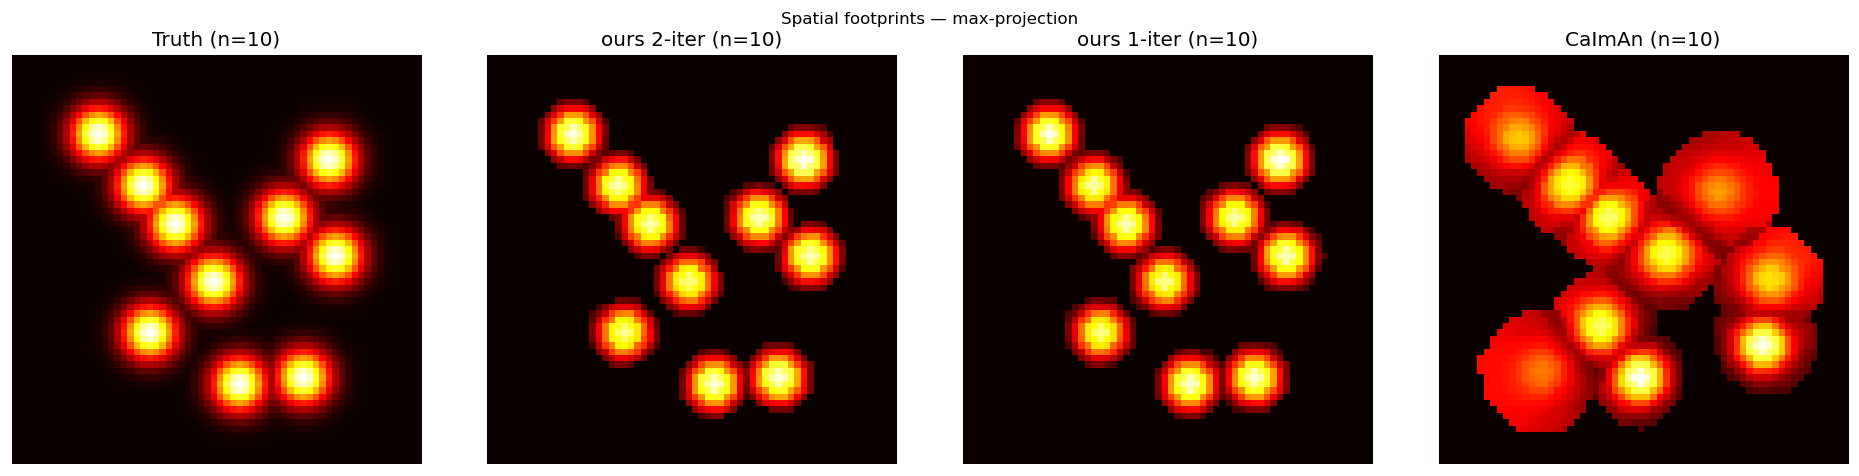

In [11]:
# --- Spatial overlays ------------------------------------------------------
def overlay(A_dense_or_sp, dims):
    A = np.asarray(A_dense_or_sp.todense() if sp.issparse(A_dense_or_sp) else A_dense_or_sp)
    if A.shape[1] == 0:
        return np.zeros(dims)
    return A.reshape(dims[0], dims[1], A.shape[1]).max(axis=2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(A_true.max(axis=1).reshape(H, W), cmap='hot')
axes[0].set_title(f'Truth (n={K})'); axes[0].axis('off')
axes[1].imshow(overlay(A_ours,  (H, W)), cmap='hot')
axes[1].set_title(f'ours 2-iter (n={A_ours.shape[1]})'); axes[1].axis('off')
axes[2].imshow(overlay(A_ours1, (H, W)), cmap='hot')
axes[2].set_title(f'ours 1-iter (n={A_ours1.shape[1]})'); axes[2].axis('off')
axes[3].imshow(overlay(A_caiman, (H, W)), cmap='hot')
axes[3].set_title(f'CaImAn (n={A_caiman.shape[1]})'); axes[3].axis('off')
plt.suptitle('Spatial footprints — max-projection', fontsize=10)
plt.tight_layout(); plt.show()

## 6. Temporal recovery — `C + YrA` vs `C_true`

For each true neuron we pick the matched extracted component (from §5) and compute the Pearson correlation between its noisy projected trace `C + YrA` and the true calcium trace.

We report two flavours per pipeline:
- `C` only — the OASIS-deconvolved trace
- `C + YrA` — the noisy projected trace (shape-faithful)

Both pipelines should give similar `C + YrA` correlations against truth — that's the test of whether each extraction localises the right pixels. The `C`-alone numbers will be lower because OASIS imposes the AR(1) shape constraint that subtly distorts spike timing.

In [12]:
def temporal_rs(matches, C_est, Cproj_est):
    rs_C    = np.array([pearson(C_est[ke],     C_true[kt]) for kt, ke, _ in matches])
    rs_proj = np.array([pearson(Cproj_est[ke], C_true[kt]) for kt, ke, _ in matches])
    return rs_C, rs_proj

rs_C_ours,   rs_proj_ours   = temporal_rs(matches_ours,   C_ours,   Cproj_ours)
rs_C_ours1,  rs_proj_ours1  = temporal_rs(matches_ours1,  C_ours1,  Cproj_ours1)
rs_C_caiman, rs_proj_caiman = temporal_rs(matches_caiman, C_caiman, Cproj_caiman)

print(f'                            ours(2)   ours(1)    caiman')
print(f'mean r  (C only)            {rs_C_ours.mean():.3f}     {rs_C_ours1.mean():.3f}     {rs_C_caiman.mean():.3f}')
print(f'mean r  (C + YrA)           {rs_proj_ours.mean():.3f}     {rs_proj_ours1.mean():.3f}     {rs_proj_caiman.mean():.3f}')
print(f'min  r  (C + YrA)           {rs_proj_ours.min():.3f}     {rs_proj_ours1.min():.3f}     {rs_proj_caiman.min():.3f}')
print()
print('Per-neuron Pearson r against true calcium trace:')
print(f'  true  ours(2)C  ours(2)C+YrA  ours(1)C  ours(1)C+YrA  caimanC  caiman C+YrA')
for k in range(K):
    print(f'   {k:2d}   {rs_C_ours[k]:.3f}       {rs_proj_ours[k]:.3f}       {rs_C_ours1[k]:.3f}       {rs_proj_ours1[k]:.3f}      {rs_C_caiman[k]:.3f}      {rs_proj_caiman[k]:.3f}')

                            ours(2)   ours(1)    caiman
mean r  (C only)            0.583     0.581     0.344
mean r  (C + YrA)           0.971     0.971     0.331
min  r  (C + YrA)           0.964     0.964     -0.059

Per-neuron Pearson r against true calcium trace:
  true  ours(2)C  ours(2)C+YrA  ours(1)C  ours(1)C+YrA  caimanC  caiman C+YrA
    0   0.612       0.972       0.612       0.972      0.901      0.877
    1   0.619       0.973       0.613       0.973      0.635      0.604
    2   0.609       0.964       0.577       0.964      0.097      0.100
    3   0.578       0.964       0.584       0.964      0.719      0.695
    4   0.476       0.970       0.477       0.970      0.019      0.014
    5   0.618       0.974       0.618       0.974      0.020      0.019
    6   0.470       0.968       0.479       0.968      0.656      0.634
    7   0.574       0.977       0.581       0.977      0.425      0.411
    8   0.636       0.975       0.627       0.975      -0.045      -0.059
   

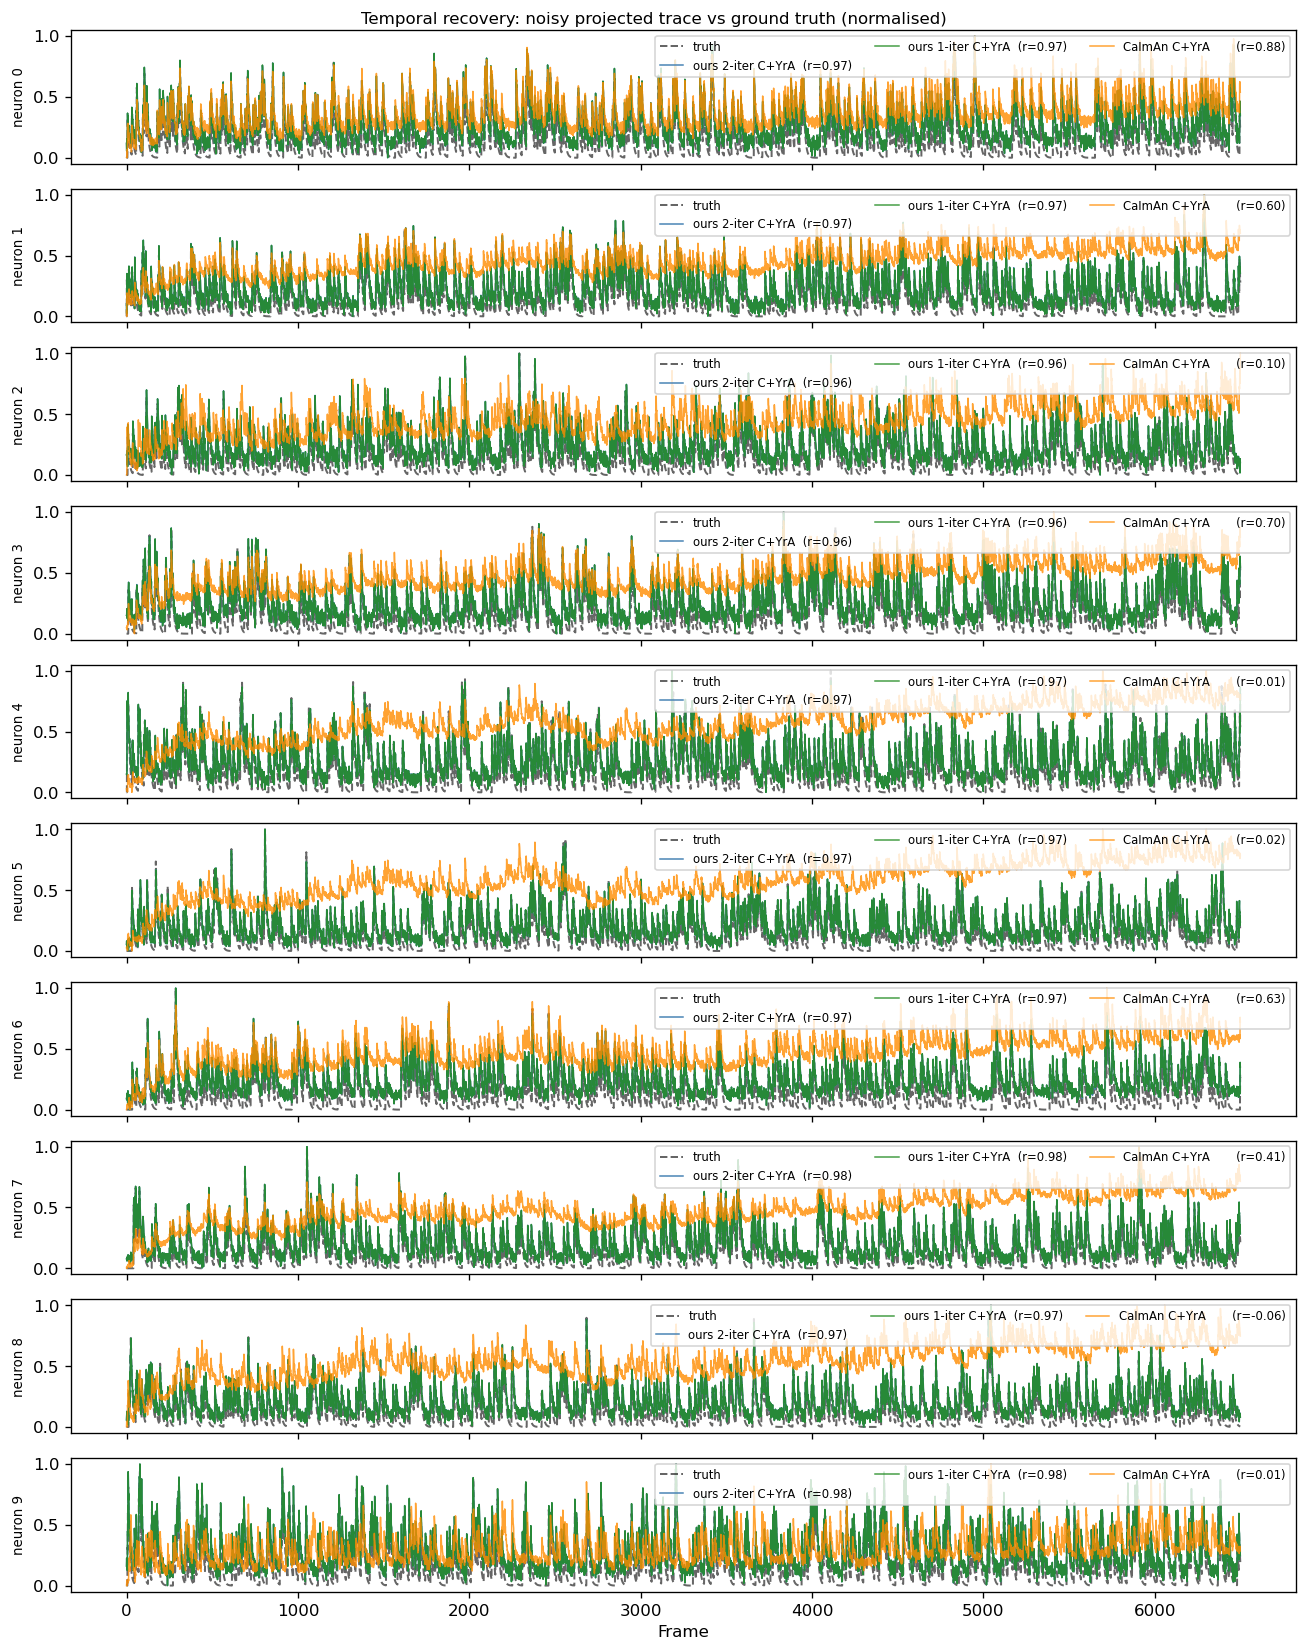

In [13]:
# --- Per-neuron trace comparison plot --------------------------------------
fig, axes = plt.subplots(K, 1, figsize=(11, 1.4 * K), sharex=True)
if K == 1: axes = [axes]
for ax, k in zip(axes, range(K)):
    _, ke_ours,   _ = matches_ours[k]
    _, ke_ours1,  _ = matches_ours1[k]
    _, ke_caiman, _ = matches_caiman[k]

    ax.plot(norm01(C_true[k]), lw=1.2, color='black', ls='--', alpha=0.6, label='truth')
    if ke_ours >= 0:
        ax.plot(norm01(Cproj_ours[ke_ours]),   lw=0.9, color='steelblue',
                label=f'ours 2-iter C+YrA  (r={pearson(Cproj_ours[ke_ours], C_true[k]):.2f})')
    if ke_ours1 >= 0:
        ax.plot(norm01(Cproj_ours1[ke_ours1]), lw=0.9, color='forestgreen', alpha=0.85,
                label=f'ours 1-iter C+YrA  (r={pearson(Cproj_ours1[ke_ours1], C_true[k]):.2f})')
    if ke_caiman >= 0:
        ax.plot(norm01(Cproj_caiman[ke_caiman]), lw=0.9, color='darkorange', alpha=0.8,
                label=f'CaImAn C+YrA       (r={pearson(Cproj_caiman[ke_caiman], C_true[k]):.2f})')
    ax.set_ylabel(f'neuron {k}', fontsize=8)
    ax.legend(loc='upper right', fontsize=7, ncol=3)
axes[-1].set_xlabel('Frame')
plt.suptitle('Temporal recovery: noisy projected trace vs ground truth (normalised)', fontsize=10)
plt.tight_layout(); plt.show()

## 7. Summary

| metric | ours | CaImAn |
|--------|------|--------|
| K extracted | filled by cell 5 | filled by cell 5 |
| mean spatial r | filled by cell 5 | filled by cell 5 |
| mean temporal r (C only) | filled by cell 6 | filled by cell 6 |
| mean temporal r (C + YrA) | filled by cell 6 | filled by cell 6 |
| wall time (s) | filled by cell 7 | filled by cell 7 |

The cell below prints the same numbers in tabular form for easy copy-paste.

In [ ]:
print('=================================================================')
print(f'{"metric":<30} {"ours(2)":>9} {"ours(1)":>9} {"caiman":>9}')
print('=================================================================')
print(f'{"K extracted":<30} {A_ours.shape[1]:>9d} {A_ours1.shape[1]:>9d} {A_caiman.shape[1]:>9d}')
print(f'{"matched (>0.7 spatial r)":<30} '
      f'{(rs_A_ours > 0.7).sum():>9d} {(rs_A_ours1 > 0.7).sum():>9d} {(rs_A_caiman > 0.7).sum():>9d}')
print(f'{"unmatched (FP candidates)":<30} {fp_ours:>9d} {fp_ours1:>9d} {fp_caiman:>9d}')
print(f'{"mean spatial r":<30} {rs_A_ours.mean():>9.3f} {rs_A_ours1.mean():>9.3f} {rs_A_caiman.mean():>9.3f}')
print(f'{"mean temporal r (C only)":<30} '
      f'{rs_C_ours.mean():>9.3f} {rs_C_ours1.mean():>9.3f} {rs_C_caiman.mean():>9.3f}')
print(f'{"mean temporal r (C + YrA)":<30} '
      f'{rs_proj_ours.mean():>9.3f} {rs_proj_ours1.mean():>9.3f} {rs_proj_caiman.mean():>9.3f}')
print(f'{"wall time (s)":<30} {t_ours:>9.2f} {t_ours1:>9.2f} {t_caiman:>9.2f}')
print('=================================================================')

## 8. Realistic miniscope movie — stress test

The simple synthetic movie above used isotropic Gaussian footprints, white Gaussian noise,
and a rank-1 background — ideal conditions for any CNMF variant.

Here we repeat the comparison on a movie generated by `make_miniscope_movie`, which adds
the messy features a real 1-photon recording contains:

- **Heterogeneous neuron shapes** — elliptical with random eccentricity and orientation
- **Per-neuron AR(1) decay** — `g` sampled in [0.86, 0.96] rather than fixed at 0.9
- **Multi-component drifting background** — 5 spatial components at different spatial
  and temporal scales (not rank-1)
- **Ghost cells** — large out-of-focus blurry blobs that look like dim neurons and are
  the dominant false-positive source in real 1p data
- **Vasculature pulsation** — blood-vessel striping at heart-rate frequency
- **Radial vignetting** — dimmer corners
- **Photobleaching** — exponential intensity decay over the recording
- **Shot noise + read noise** — Poisson photon noise and Gaussian read noise
- **8-bit quantisation** — integer pixel values 0–255

Parameters are otherwise kept the same (`min_pnr` raised to 8 to compensate for
the elevated background).

The key questions:
1. Does the iteration gap (ours 2-iter vs ours 1-iter vs CaImAn 1-cycle) change on harder data?
2. Are ghost cells preferentially picked up by one algorithm?
3. Does CaImAn's per-component AR estimation help when `g` truly varies?

In [ ]:
from tests.miniscope_simulator import make_miniscope_movie

data_r = make_miniscope_movie(
    n_neurons=10, dims=(64, 64), T=6500,
    fps=20.0,
    bg_strength=4.0, bg_n_components=5,
    n_ghost_cells=6,
    vasculature=True,
    vignette_strength=0.4,
    photobleach_tau_factor=3.0,
    shot_noise=True, quantize_8bit=True,
    seed=1,
)

movie_r  = data_r['movie']        # (T, H, W) float32
A_true_r = data_r['A_true']       # (H*W, K) — true neurons only (no ghost cells)
C_true_r = data_r['C_true']       # (K, T)
g_true_r = data_r['g_true']       # (K,) per-neuron AR decay
K_r      = C_true_r.shape[0]

print(f'Realistic movie:    {movie_r.shape}')
print(f'True neurons:       {K_r}  (+ 6 ghost cells in background)')
print(f'Read noise std:     {data_r["sn_true"]:.3f}')
print(f'AR(1) decay range:  [{g_true_r.min():.3f}, {g_true_r.max():.3f}]  (vs fixed 0.9 in simple movie)')

In [ ]:
# --- Run our CNMFe (2-iter and 1-iter) on the realistic movie ---------------
params_r2 = CNMFeParams(
    sigma=3.0, min_corr=0.8, min_pnr=8.0,
    n_iter_main=2, n_iter_temporal=2, mc_n_iter=1,
    spatial_max_thr=0.1, merge_thr_corr=0.85, merge_thr_overlap=0.5,
    global_ar=False,  # per-neuron g estimated from each C_raw[k]
    n_jobs=-1,
)
params_r1 = CNMFeParams(
    sigma=3.0, min_corr=0.8, min_pnr=8.0,
    n_iter_main=1, n_iter_temporal=2, mc_n_iter=1,
    spatial_max_thr=0.1, merge_thr_corr=0.85, merge_thr_overlap=0.5,
    global_ar=False,  # per-neuron g estimated from each C_raw[k]
    n_jobs=-1,
)

t0 = time.time()
ours_r2 = CNMFe(params_r2).fit(movie_r, do_motion_correction=False)
t_ours_r2 = time.time() - t0
print(f'ours 2-iter (realistic): K = {ours_r2.A.shape[1]}   wall = {t_ours_r2:.2f}s')

t0 = time.time()
ours_r1 = CNMFe(params_r1).fit(movie_r, do_motion_correction=False)
t_ours_r1 = time.time() - t0
print(f'ours 1-iter (realistic): K = {ours_r1.A.shape[1]}   wall = {t_ours_r1:.2f}s')

In [ ]:
# --- Run CaImAn on the realistic movie -------------------------------------
mmap_base_r = os.path.join(mmap_dir, 'caiman_movie_r_')
fname_mmap_r = cm.save_memmap([movie_r.astype(np.float32)],
                              base_name=mmap_base_r, order='C')
Yr_r, mmap_dims_r, mmap_T_r = cm.load_memmap(fname_mmap_r)
images_r = Yr_r.T.reshape((mmap_T_r,) + mmap_dims_r, order='F')

opts_dict_r = dict(opts_dict)   # copy aligned opts; override movie-specific fields
opts_dict_r.update({
    'fnames':   [fname_mmap_r],
    'min_pnr':  8.0,            # higher threshold for ghost rejection
})
opts_r = params_module.CNMFParams(params_dict=opts_dict_r)

# Shut down joblib's loky workers before CaImAn starts its cluster.
get_reusable_executor().shutdown(wait=True)

c_r, dview_r, n_proc_r = cm.cluster.setup_cluster(
    backend='multiprocessing', n_processes=1, single_thread=True
)
try:
    t0 = time.time()
    cnm_r = cnmf_module.CNMF(n_processes=1, dview=dview_r, Ain=None, params=opts_r)
    cnm_r.fit(images_r)
    t_caiman_r = time.time() - t0
finally:
    cm.cluster.stop_server(dview=dview_r)

A_caiman_r   = cnm_r.estimates.A
C_caiman_r   = np.asarray(cnm_r.estimates.C)
YrA_caiman_r = np.asarray(cnm_r.estimates.YrA) if cnm_r.estimates.YrA is not None else \
               np.zeros_like(C_caiman_r)
Cproj_caiman_r = C_caiman_r + YrA_caiman_r

print(f'caiman (realistic): K = {A_caiman_r.shape[1]}   wall = {t_caiman_r:.2f}s')

In [ ]:
# --- Metrics on the realistic movie ----------------------------------------
A_r2 = ours_r2.A;  Cproj_r2 = ours_r2.C + ours_r2.YrA
A_r1 = ours_r1.A;  Cproj_r1 = ours_r1.C + ours_r1.YrA

matches_r2 = match_components_by_truth(A_r2,      A_true_r)
matches_r1 = match_components_by_truth(A_r1,      A_true_r)
matches_rc = match_components_by_truth(A_caiman_r, A_true_r)

def summary_row(matches, A_est, Cproj_est, C_true_):
    rs_A = np.array([m[2] for m in matches])
    rs_T = np.array([pearson(Cproj_est[ke], C_true_[kt]) for kt, ke, _ in matches])
    fp   = A_est.shape[1] - (rs_A > 0.7).sum()
    return rs_A, rs_T, fp

rs_A_r2, rs_T_r2, fp_r2 = summary_row(matches_r2, A_r2,      Cproj_r2,      C_true_r)
rs_A_r1, rs_T_r1, fp_r1 = summary_row(matches_r1, A_r1,      Cproj_r1,      C_true_r)
rs_A_rc, rs_T_rc, fp_rc = summary_row(matches_rc, A_caiman_r, Cproj_caiman_r, C_true_r)

print('=================================================================')
print(f'Realistic movie (n_true={K_r})')
print(f'{"metric":<30} {"ours(2)":>9} {"ours(1)":>9} {"caiman":>9}')
print('=================================================================')
print(f'{"K extracted":<30} {A_r2.shape[1]:>9d} {A_r1.shape[1]:>9d} {A_caiman_r.shape[1]:>9d}')
print(f'{"matched (>0.7 spatial r)":<30} '
      f'{(rs_A_r2 > 0.7).sum():>9d} {(rs_A_r1 > 0.7).sum():>9d} {(rs_A_rc > 0.7).sum():>9d}')
print(f'{"unmatched (FP candidates)":<30} {fp_r2:>9d} {fp_r1:>9d} {fp_rc:>9d}')
print(f'{"mean spatial r":<30} {rs_A_r2.mean():>9.3f} {rs_A_r1.mean():>9.3f} {rs_A_rc.mean():>9.3f}')
print(f'{"mean temporal r (C + YrA)":<30} {rs_T_r2.mean():>9.3f} {rs_T_r1.mean():>9.3f} {rs_T_rc.mean():>9.3f}')
print(f'{"wall time (s)":<30} {t_ours_r2:>9.2f} {t_ours_r1:>9.2f} {t_caiman_r:>9.2f}')
print('=================================================================')

# Spatial overlay
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(A_true_r.max(axis=1).reshape(H, W), cmap='hot')
axes[0].set_title(f'Truth (n={K_r})'); axes[0].axis('off')
axes[1].imshow(overlay(A_r2,      (H, W)), cmap='hot')
axes[1].set_title(f'ours 2-iter (n={A_r2.shape[1]})'); axes[1].axis('off')
axes[2].imshow(overlay(A_r1,      (H, W)), cmap='hot')
axes[2].set_title(f'ours 1-iter (n={A_r1.shape[1]})'); axes[2].axis('off')
axes[3].imshow(overlay(A_caiman_r, (H, W)), cmap='hot')
axes[3].set_title(f'CaImAn (n={A_caiman_r.shape[1]})'); axes[3].axis('off')
plt.suptitle('Realistic movie — spatial footprints', fontsize=10)
plt.tight_layout(); plt.show()

## 9. Known limitations of this comparison

The numbers above should be read with these caveats in mind.

### Things this comparison still can't fully equalise

**1. Iteration strategy, not just iteration count**
`n_iter_main=1` in our model gives one full spatial→temporal→merge cycle, but our
temporal step always uses the AR(1) constraint (OASIS) from the start. CaImAn's single
cycle runs temporal first with `p=0` (unconstrained NNLS), then after merging reruns
with `p=1`. That two-phase approach can give better initialisation when the first temporal
pass is noisy. Our `ours (1 iter)` column does not replicate that behaviour.

**2. CaImAn normalises component traces in the spatial solve**
CaImAn's spatial update passes traces through `StandardScaler(with_mean=False)` before
LassoLars fitting, normalising each component to unit variance. Our `update_spatial`
uses raw traces. When component amplitudes vary widely (real recordings often have
10× amplitude differences across neurons), CaImAn's normalisation reduces the chance
that a bright component over-shadows a dim one during pixel assignment.

**3. Per-component AR(1) decay vs pooled global**
CaImAn estimates `g` per neuron per iteration. Our model fixes `g` from a pooled
estimate to prevent fudge-factor drift — correct for recordings where all neurons share
an indicator, but suboptimal when `g` genuinely varies (different depths, mixed GCaMP
generations). The realistic movie exercises this: `g_true` spans ~0.86–0.96.

Our model now exposes `global_ar=False` on `CNMFeParams` to switch to per-neuron
estimation. Both modes estimate `g` once from `C_raw` at init and cache it across all
BCD iterations — neither re-estimates from deconvolved traces, so there is no
fudge-factor drift in either mode.

**4. `evaluate_components` is not called**
CaImAn ships a CNN-based classifier + SNR + spatial-correlation quality filter
(`cnm.estimates.evaluate_components`). The notebook omits it so the comparison is
"raw output vs raw output". On real data this filtering is CaImAn's main precision
advantage — it rejects ghost cells, split neurons, and low-SNR components. Omitting it
artificially inflates CaImAn's false-positive count here.

**5. No real-recording validation**
CaImAn has been benchmarked on hundreds of real 1-photon recordings, including
simultaneous electrophysiology ground truth. Our implementation has only been tested on
synthetic data. A performance gap on synthetic data does not guarantee the same gap on
real recordings, in either direction.

**6. Background complexity**
Even the realistic simulator uses a sum-of-separable-rank-1 components for background.
Real recordings have blood-vessel ring artefacts, neuropil correlation structure, and
global hemodynamic signals that are not separable and are not captured by either the
ring model or the simulator.